In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dt=pd.read_csv("netflix.csv")
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8807 non-null   str    
 1   type          8807 non-null   str    
 2   title         8807 non-null   str    
 3   director      6173 non-null   str    
 4   cast          7982 non-null   str    
 5   country       7976 non-null   str    
 6   date_added    8797 non-null   str    
 7   release_year  8807 non-null   int64  
 8   rating        8803 non-null   str    
 9   duration      8804 non-null   str    
 10  Unnamed: 10   0 non-null      float64
 11  Unnamed: 11   0 non-null      float64
dtypes: float64(2), int64(1), str(9)
memory usage: 825.8 KB


In [3]:
dt.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,Unnamed: 10,Unnamed: 11
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,NaN,NaN


In [4]:
dt.tail(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,Unnamed: 10,Unnamed: 11
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,NaN,NaN
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,NaN,NaN
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,NaN,NaN


In [5]:
dt.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
Unnamed: 10     8807
Unnamed: 11     8807
dtype: int64

In [6]:
dt['cast']=dt['cast'].fillna('Unknown')
dt['country']=dt['country'].fillna('Unknown')
dt['director']=dt['director'].fillna('Unknown')
dt['rating']=dt['rating'].fillna('Unknown')
dt['duration']=dt['duration'].fillna('Unknown')
dt.isnull().sum()

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added        10
release_year       0
rating             0
duration           0
Unnamed: 10     8807
Unnamed: 11     8807
dtype: int64

In [7]:
dt=dt.drop(['date_added'],axis=1)
dt=dt.drop(['Unnamed: 10'],axis=1)
dt=dt.drop(['Unnamed: 11'],axis=1)
dt.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
release_year    0
rating          0
duration        0
dtype: int64

In [8]:
dt['show_id']=dt['show_id'].str.replace('s','',regex=False)
dt['show_id']=dt['show_id'].astype(int)
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   int64
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   release_year  8807 non-null   int64
 7   rating        8807 non-null   str  
 8   duration      8807 non-null   str  
dtypes: int64(2), str(7)
memory usage: 619.4 KB


In [9]:
dt['release_year']=pd.to_datetime(dt['release_year'],format='%Y')
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   int64         
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      8807 non-null   str           
 4   cast          8807 non-null   str           
 5   country       8807 non-null   str           
 6   release_year  8807 non-null   datetime64[us]
 7   rating        8807 non-null   str           
 8   duration      8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(7)
memory usage: 619.4 KB


In [10]:
dt['type']=dt['type'].map({
    'Movie' : 1,
   'TV Show' : 2,
})
dt['type']=dt['type'].astype('int64')
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   int64         
 1   type          8807 non-null   int64         
 2   title         8807 non-null   str           
 3   director      8807 non-null   str           
 4   cast          8807 non-null   str           
 5   country       8807 non-null   str           
 6   release_year  8807 non-null   datetime64[us]
 7   rating        8807 non-null   str           
 8   duration      8807 non-null   str           
dtypes: datetime64[us](1), int64(2), str(6)
memory usage: 619.4 KB


In [11]:
dt.set_index(['show_id','type'],inplace=True)
dt

,,title,director,cast,country,release_year,rating,duration
show_id,type,,,,,,,
1,1,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020-01-01,PG-13,90 min
2,2,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-01-01,TV-MA,2 Seasons
3,2,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-01-01,TV-MA,1 Season
4,2,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-01-01,TV-MA,1 Season
5,2,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-01-01,TV-MA,2 Seasons
...,...,...,...,...,...,...,...,...
8803,1,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007-01-01,R,158 min
8804,2,Zombie Dumb,Unknown,Unknown,Unknown,2018-01-01,TV-Y7,2 Seasons
8805,1,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009-01-01,R,88 min


In [29]:
dt.duplicated().sum()

np.int64(0)

In [30]:
dt=dt.drop_duplicates()
dt

,,title,director,cast,country,release_year,rating,duration
show_id,type,,,,,,,
1,1,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020-01-01,PG-13,90 min
2,2,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-01-01,TV-MA,2 Seasons
3,2,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-01-01,TV-MA,1 Season
4,2,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-01-01,TV-MA,1 Season
5,2,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-01-01,TV-MA,2 Seasons
...,...,...,...,...,...,...,...,...
8803,1,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007-01-01,R,158 min
8804,2,Zombie Dumb,Unknown,Unknown,Unknown,2018-01-01,TV-Y7,2 Seasons
8805,1,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009-01-01,R,88 min


C:\Users\acer\AppData\Local\Temp\ipykernel_11920\3216849354.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dt, x='type', palette=['Cyan','Blue'])


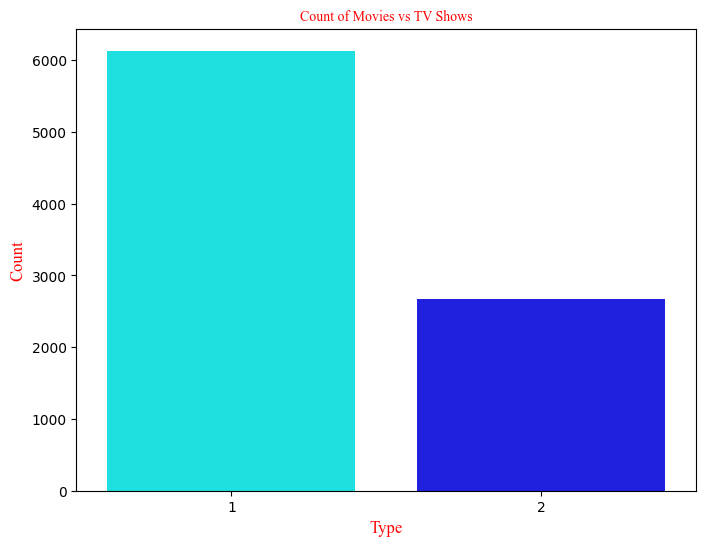

In [13]:
plt.figure(figsize=(8, 6))

sns.countplot(data=dt, x='type', palette=['Cyan','Blue'])
plt.title('Count of Movies vs TV Shows', fontsize=16, font='Times New Roman', color='Red')
plt.xlabel('Type', fontsize=12, font='Times New Roman', color='Red')
plt.ylabel('Count', fontsize=12, font='Times New Roman', color='Red')
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_11920\1639077787.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ratings.index, y=ratings.values, palette='magma')


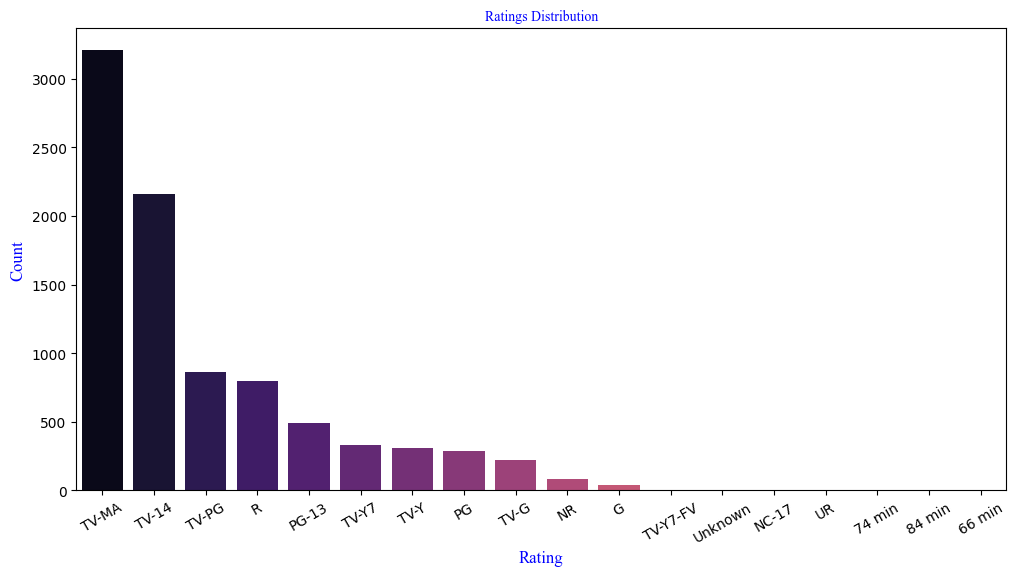

In [14]:
plt.figure(figsize=(12, 6))
ratings = dt['rating'].value_counts()
sns.barplot(x=ratings.index, y=ratings.values, palette='magma')
plt.title('Ratings Distribution', fontsize=16, font='Times New Roman', color='Blue')
plt.xlabel('Rating', fontsize=12, font='Times New Roman', color='Blue')
plt.ylabel('Count', fontsize=12, font='Times New Roman', color='Blue')
plt.xticks(rotation=30)
plt.show()